# Hydrostatics of submerged cylinder

## Summary of the Notebook

This notebook demonstrates a numerical approach to evaluate the submerged depth of arbitrarily shaped bodies, specifically cylindrical structures, in a fluid. It includes the following steps:

1. **Constants Definition**: Physical constants such as gravitational acceleration, water density, and domain dimensions are defined.
2. **Cylindrical Structures**: Cylindrical objects are modeled with their geometry and nodes, and their elements are visualized.
3. **Static Pressure Calculation**: A function is implemented to compute the static pressure distribution in the fluid.
4. **Visualization**: The static pressure field and the cylindrical structures are plotted for better understanding.
5. **Force Calculation**: The forces acting on the cylindrical structures due to the pressure distribution are computed using numerical integration.
6. **Draft Calculation**: The submerged depth (draft) of floating cylindrical bodies is determined by solving a nonlinear equation using numerical optimization.
7. **Final Visualization**: The pressure field and the equilibrium positions of the floating cylinders are visualized.

This approach provides insights into hydrostatics and the interaction of submerged bodies with fluid pressure fields.

In [14]:
import numpy as np
import math as math
from scipy import optimize
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import warnings  

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

# Hydrostatics of a Submerged Tunnel Element

## Introduction
In this notebook, we will analyze the hydrostatics of a cylindrical floating body, such as a tunnel element. We will move from basic definitions to an interactive simulation.

**Learning Objectives:**
1.  **Geometry:** How to model a circular object using nodes and elements.
2.  **Hydrostatics:** How to calculate static pressure fields.
3.  **Numerical Integration:** Using Gaussian Quadrature to calculate total forces ($F_x, F_z$) from pressure.
4.  **Equilibrium:** Solving the non-linear problem of finding the *draft* (submerged depth) for a given weight.

Let's start by defining the physical constants and the domain.

## Define Variables

- `g`: Gravitational acceleration (m/s²).
- `rhoW`: Density of water (kg/m³).
- `d`: Depth of water (m).

For visualising the pressure contour

- `xdom`: Tuple defining the x-domain range (start, end) for the simulation (m).
- `dx`: Step size in the x-direction (m).
- `dz`: Step size in the z-direction (m).

In [15]:
# Constants 
g = 9.81  #m/s2
rhoW = 1000  #kg/m3
d = 10 #m (water-depth)
xdom = (0, 30)
dx = 1
dz = 1

## 1. Defining the Geometry of Cylindrical Structures

To define the geometry of a cylindrical structure we will use the concept of finite elements. It will therefore serve as a simple problem to understand the FE concepts.

To calculate forces on a curved shape like a cylinder, we cannot just use a single formula. Instead, we discretize the shape into small straight lines called **elements**.

### The `Cyl` Class
We create a class `Cyl` that generates a mesh of nodes (points) and elements (connectivity array `self.Ele`) representing the cylinder.

*   **Inputs:** It takes the center position `(x0, z0)`, radius (`R`), and angular step size (`dth`) as inputs.
*   **Nodes:** Define points $(x, z)$ on the circle.
*   **Elements:** Line segments connecting two nodes. An array containing the node associated with the element in the anti-clockwise order.
*   **Pressure Field:** We will later assign a pressure value `P` to every node. This will be used later for calculating the buoyant force on the structure.

The function `plotEle()` will plot the cylinder in the 2D space, based on the provided position of the centre `(x0, z0)` and the radius `R` of the cylinder

In [16]:
class Cyl:
    def __init__(self, x0, z0, R, dth):
        thMat = np.arange(0, 360, dth) #deg
        cx = x0 + R*np.cos( np.deg2rad(thMat) )
        cz = z0 + R*np.sin( np.deg2rad(thMat) )
        self.cx = cx
        self.cz = cz
        self.NodeC = [ [x, z] for x,z in zip (cx, cz) ]
        self.nNode = len(self.NodeC)
        self.Ele = [ [n1, n2] for n1,n2 in 
                    zip( range(0,self.nNode-1), range(1,self.nNode)) ]
        self.Ele.append([self.nNode-1, 0])
        self.nEle = len(self.Ele)
        self.P = np.zeros(self.nNode)
        
    def plotEle(self):        
        for iEle in range(0,self.nEle):
            n1, n2 = self.Ele[iEle]
            n1 = int(round(n1))
            n2 = int(round(n2))
            plt.plot( [self.NodeC[n1][0], self.NodeC[n2][0]],
                     [self.NodeC[n1][1], self.NodeC[n2][1]],
                     lw=3, color='k')        
            
        
# Cyl(x0, z0, R, dthDeg):

## 2. Calculating Forces: Numerical Integration

Once we know the pressure at the nodes, we need to calculate the total force acting on the cylinder. We use the **Gaussian Quadrature** method (2-point) to integrate the pressure over the surface.

The force vector $\vec{F}$ is the integral of a scalar field (in this case the pressure $p$) acting normal to the surface $\vec{n}$ along the entire domain :

$$
\vec{F} = \int_\Omega p \, \vec{n} \, d\Omega
$$

### The Algorithm
The function `gaussQuad2P` performs this integration numerically:
1.  It loops over every **element** of the cylinder.
2.  It calculates the **normal vector** ($n_x, n_z$) and length of each element.
3.  It samples the pressure at two specific internal points (Gauss points).
4.  It sums up the contributions to find the total horizontal ($F_x$) and vertical ($F_z$) forces.

This method ensures accurate numerical integration of the scalar field over the surface.

In [17]:
def gaussQuad2P( nEle, nNode, Ele, NodeC, P):
    sumFx = 0.0
    sumFz = 0.0
    for iEle in range(0,nEle):
        n1, n2 = Ele[iEle]
        n1 = int(round(n1))
        n2 = int(round(n2))
        x1,z1 = NodeC[n1]
        x2,z2 = NodeC[n2]
        p1 = P[n1]
        p2 = P[n2]
        
        lele = np.sqrt( (x2-x1)**2 + (z2-z1)**2 )        
        nx = (z2-z1)/lele
        nz = -(x2-x1)/lele
        
        ep1 = 0.5*(1-1/np.sqrt(3))
        ep2 = 0.5*(1+1/np.sqrt(3))
        q1p = (1-ep1)*p1 + ep1*p2
        q2p = (1-ep2)*p1 + ep2*p2
        sumFx += (q1p + q2p)*lele/2*(-nx)
        sumFz += (q1p + q2p)*lele/2*(-nz)
    return sumFx, sumFz

pass

## 3. The Hydrostatic Pressure Field

Before we can calculate forces, we need to define the water pressure. In hydrostatics, pressure increases linearly with depth.

$$ P(z) = -\rho \cdot g \cdot z $$

The function statPressure` calculates the static pressure at a given point in the fluid. 
*   **Input:** $x$ and $z$, x-coordinate(s) and z-coordinate(s) of the point(s) in meter.
*   **Output:** $Ps$: Static pressure at the given point(s) (Pa).

#### Process:
- The function computes the pressure using the formula `Ps = -rhoW * g * z`, where `rhoW` is the density of water and `g` is the gravitational acceleration.
- If the calculated pressure is negative (above the water surface), it is set to zero using `np.maximum`.

In [18]:
# Function to define static pressure
def statPressure(x,z):
    Ps = -rhoW * g * z
    Psz = 0*Ps
    Ps = np.maximum(Ps, Psz)
    return Ps

## Initilise cylinders

Now using the class `Cyl` we initilise two cylinders, one fully sumerged and one partially submerged.

In [19]:
cyl1 = Cyl(10, -5, 2, 0.1)
cyl2 = Cyl(20, 0, 2, 0.1)

## Visualize everything

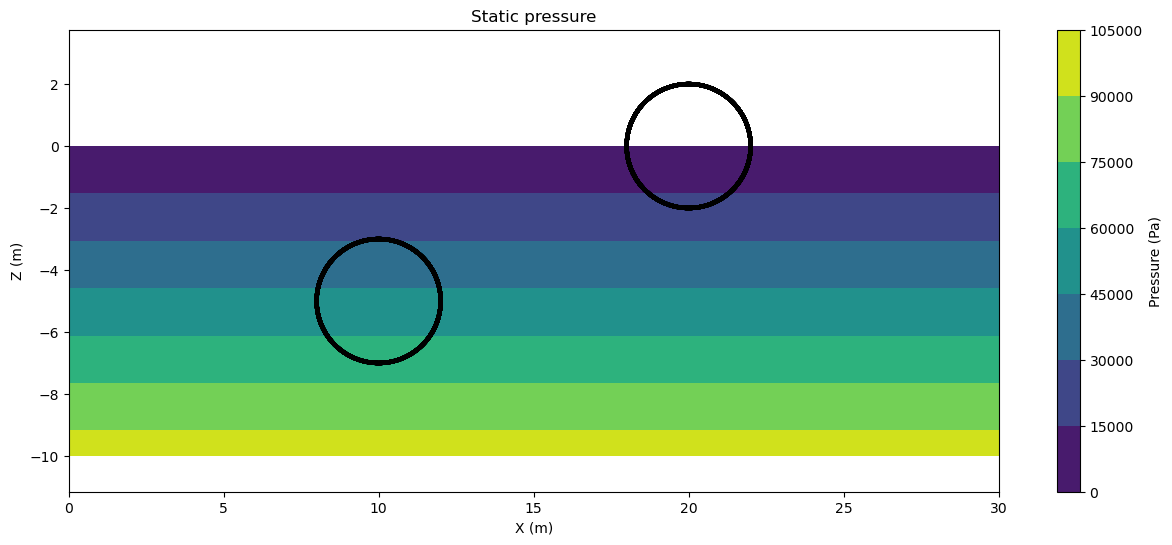

In [20]:
[X, Z] = np.meshgrid( np.arange(xdom[0], xdom[1]+1, 1), np.arange(-d, 0+1, 1) )
Ps = statPressure(X, Z)

plt.figure(1)
plt.contourf(X, Z, Ps)
plt.title('Static pressure')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
cbar = plt.colorbar()
cbar.set_label('Pressure (Pa)')

cyl1.plotEle()
cyl2.plotEle()

#plt.grid("on")
plt.axis("equal")
plt.show()
pass

## 4. Compute Hydrostatic Forces

Now we combine the geometry and the pressure field.
1.  We map the pressure `Ps` to the nodes of the two cylinders. For this we pass the array of all nodes of the cylinder in the `statPressure` function and obtain the corresponsidoing static pressure.
2.  We call our integration function `gaussQuad2P` to compute the total forces.

**Expected Result:**
*   **$F_x$:** Should be (close to) zero, as horizontal forces cancel each other out on a symmetric body.
*   **$F_z$:** This is the **Buoyancy Force**. According to Archimedes, this should equal the weight of the displaced water.

### THINK:

How would you modify the function to analyse the dynamic pressure on the cylinder due to wave action?

In [21]:
cyl1.P = statPressure( cyl1.cx, cyl1.cz )
cyl2.P = statPressure( cyl2.cx, cyl2.cz )

In [22]:
cyl1.Fx, cyl1.Fz = gaussQuad2P( cyl1.nEle, cyl1.nNode, 
                               cyl1.Ele, cyl1.NodeC, cyl1.P )
cyl2.Fx, cyl2.Fz = gaussQuad2P( cyl2.nEle, cyl2.nNode, 
                               cyl2.Ele, cyl2.NodeC, cyl2.P )

print("Cyl1 Fx Fz", cyl1.Fx, cyl1.Fz)
print("Cyl2 Fx Fz ", cyl2.Fx, cyl2.Fz)

Cyl1 Fx Fz -5.0107473725802265e-11 123276.0331401297
Cyl2 Fx Fz  -1.9287030306180952e-11 61638.01657006472


## 5. Finding the Draft

So far, we calculated the force for a *fixed* position. Now we reverse the problem: *We assume we know the force, let's say the weight of the body, and we want to find depth of submergence, or the draft, of the body.*

For the tunnel to float, it must reach **hydrostatic equilibrium**:

$$ W = F_{buoyancy} $$

*   **Weight:** $m \cdot g$ (Downward force)
*   **Buoyancy:** Calculated by our integration function (Upward force)

### The Numerical Solver
Because the cylinder is round, the relationship between depth and buoyancy is **non-linear**. There is no simple formula to find the depth $z$.

The provided function `objective_fnc()` defines an objective function that calculates the difference (error) between the buoyant force acting on a submerged cylindrical body (based on its assumed draft) and the predefined weight of the body. We use `optimize.fsolve` to adjust the draft until the buoyant force matches the weight:

$$ F_{buoyancy}(z) - W = 0 $$

The solver "guesses" a depth, checks the force difference, and adjusts until the error is zero, thereby determining the equilibrium submerged depth of the body. This is an iterative procedure.

In [23]:
def objective_fnc(sol,*data):    
    z0 = sol
    x0, R, dth, Fztarg = data
    cyl = Cyl(x0, z0, R, dth)
    cyl.P = statPressure(cyl.cx, cyl.cz)
    cyl.Fx, cyl.Fz = gaussQuad2P(cyl.nEle, cyl.nNode, 
                                   cyl.Ele, cyl.NodeC, cyl.P)    
    return (cyl.Fz - Fztarg)

cylWei = 10000 #kg
W = cylWei * g
data = (10, 2, 0.5, W)
root = optimize.fsolve(objective_fnc,-1,args=data)
print("Numerically calculated z0 = ",root)
cyl3  = Cyl(data[0], root, data[1], data[2])

cylWei = 2000 #kg
W = cylWei * g
data = (20, 2, 0.5, W)
root = optimize.fsolve(objective_fnc,-1,args=data)
print("Numerically calculated z0 = ",root)
cyl4  = Cyl(data[0], root, data[1], data[2])

Numerically calculated z0 =  [-0.96854763]
Numerically calculated z0 =  [1.13507043]


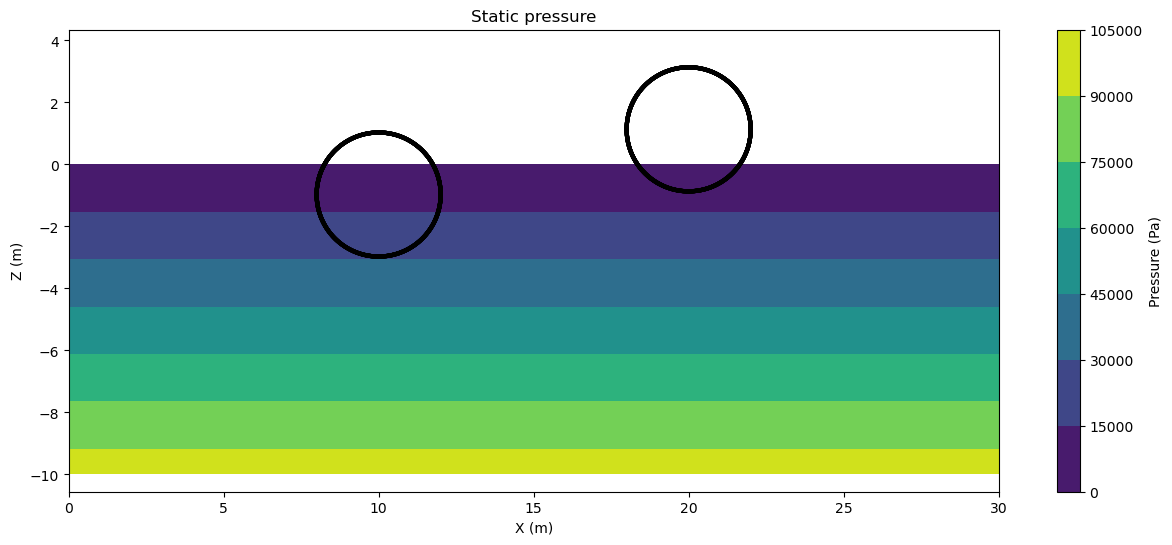

In [24]:
[X, Z] = np.meshgrid( np.arange(xdom[0], xdom[1]+1, 1), np.arange(-d, 0+1, 1) )
Ps = statPressure(X, Z)

plt.contourf(X, Z, Ps)
plt.title('Static pressure')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
cbar = plt.colorbar()
cbar.set_label('Pressure (Pa)')

cyl3.plotEle()
cyl4.plotEle()

#plt.grid("on")
plt.axis("equal")
plt.show()
pass

## 6. Analyzing the Non-Linear Behavior

To understand the stability of the tunnel, we plot the relationship between the **Required Weight** (Force) and the **Equilibrium Depth** ($z$).

### How to read this graph:
*   **X-axis (Force/Weight):** How heavy is the tunnel?
*   **Y-axis (Position z):** At what depth will it float? ($z=0$ is the water surface).

### Why is this Graph Non-Linear?
The tunnel has a **circular cross-section**. As the tunnel sinks deeper into the water, the submerged volume ($V_{submerged}$) does not increase linearly.
*   When the tunnel just touches the water, sinking 10cm displaces very little water.
*   When the tunnel is half-submerged, sinking 10cm displaces a large amount of water.

### Special Case: Neutral Buoyancy
Once the tunnel is completely underwater ($z<-R$), the buoyant force reaches its maximum and remains constant. This is because the volume of displaced water can no longer increase, regardless of how much deeper the tunnel sinks.

**What does this imply for the equilibrium?**
1. **Sinking:** If the weight exceeds this maximum limit, gravity is stronger than the maximum possible buoyancy. No equilibrium can be reached, and the tunnel will sink to the bottom.
2. **Neutral Buoyancy:** If the weight corresponds exactly to this maximum buoyant force, the tunnel achieves neutral buoyancy. Since the buoyant force is constant at all depths below the surface, the net force is zero everywhere. This means you could place the tunnel at -10m, -20m, or -50m, and it would stay there without rising or sinking.

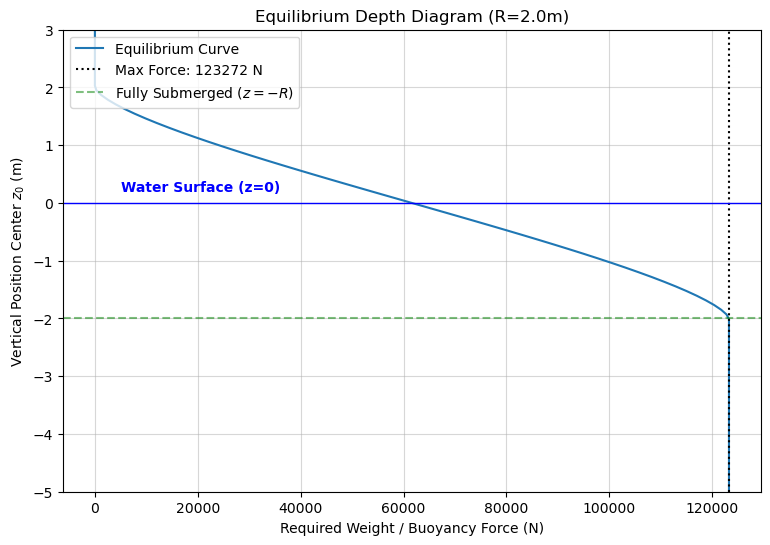

In [25]:
R = 2.0 #m

z_positions = np.linspace(-5, 3, 100) 
fz_list = []

for z in z_positions:
    # Create temp cylinder
    temp_cyl = Cyl(0, z, R, 2.0)
    
    # Calculate pressure and force
    temp_cyl.P = statPressure(temp_cyl.cx, temp_cyl.cz)
    _, fz = gaussQuad2P(temp_cyl.nEle, temp_cyl.nNode, 
                        temp_cyl.Ele, temp_cyl.NodeC, temp_cyl.P)
    fz_list.append(fz)

plt.figure(figsize=(9, 6))
plt.plot(fz_list, z_positions, label='Equilibrium Curve')

plt.axvline(x=12566*g, color='black', linestyle=':', label=f'Max Force: {12566*g:.0f} N')
plt.axhline(y=-R, color='green', linestyle='--', alpha=0.5, label='Fully Submerged ($z=-R$)')
plt.axhline(y=0, color='blue', linestyle='-', linewidth=1)
plt.text(5000, 0.2, 'Water Surface (z=0)', color='blue', fontweight='bold')

plt.title(f'Equilibrium Depth Diagram (R={R}m)')
plt.ylabel('Vertical Position Center $z_0$ (m)')
plt.xlabel('Required Weight / Buoyancy Force (N)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)
plt.ylim(-5, 3) 
plt.show()

## 7. Interactive Simulation

Finally, let's put it all together. Use the slider to change the **mass** of the tunnel and see how it affects the draft in real-time.

### Key Variables:
*   **Mass (kg):** The input mass of the tunnel structure.
*   **Weight (kN):** The downward force ($Mass \times 9.81$).
*   **Center ($z_0$):** The vertical coordinate of the cylinder's center. ($z=0$ is the water surface).
*   **Draft:** The distance from the water surface to the lowest point of the tunnel.
    $$ \text{Draft} = -z_0 + Radius $$
*   **Status:** The simulation checks if the weight is too high. If $Weight > F_{max}$, the tunnel will sink to the bottom.

``` {raw} html
<iframe
  src="../../../_static/widgets/hydrostatic_widget.html"
  width="100%" height="520" style="border:0" loading="lazy">
</iframe>
```

In [26]:
# 1. Setup: Calculate background (pressure field)
x_dom = (0, 30)
d_depth = 10

# Create Grid (from bottom to +4.5m air)
x_grid, z_grid = np.meshgrid(np.arange(x_dom[0], x_dom[1]+1, 0.5), 
                             np.arange(-d_depth, 4.5, 0.5))

# Calculate Pressure
P_background = statPressure(x_grid, z_grid)

# TRICK FOR WHITE AIR:
# Set all pressure values where Z > 0 to 'NaN' (Not a Number).
# Matplotlib does not draw these areas, so they remain white.
P_plot = P_background.copy()
P_plot[z_grid > 0.0] = np.nan 

# Estimate max buoyancy for slider limit
max_mass_est = int((np.pi * 2.0**2) * 1000) 

# 2. The Slider
slider_mass = widgets.FloatSlider(
    value=5066.0,
    min=66.0,
    max=max_mass_est + 1000.0, 
    step=500.0,
    description='Mass (kg):', # English description
    continuous_update=True,
    layout=widgets.Layout(width='60%'),
    style={'description_width': 'initial'}
)

# 3. The Update Function
def update_simulation_final(mass):
    # Constants
    R_sim = 2.0
    x_pos = 20.0 
    
    # --- PHYSICS CALCULATION ---
    weight_N = mass * g
    max_buoyancy_N = (np.pi * R_sim**2) * rhoW * g
    
    # Check: Is the tunnel too heavy?
    is_sunk = weight_N > max_buoyancy_N
    
    if not is_sunk:
        # If floating: calculate the depth
        try:
            args = (x_pos, R_sim, 2.0, weight_N)
            
            # Suppress warnings for cleaner output
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                root = optimize.fsolve(objective_fnc, -1.0, args=args)
            
            z_eq = root[0]
            
            # Create cylinder object
            sim_cyl = Cyl(x_pos, z_eq, R_sim, 2.0)
            
            # Status text with Center (z0) and Draft
            status_txt = (f"Status: FLOATING\n"
                          f"Center ($z_0$): {z_eq:.2f} m\n"
                          f"Draft: {-z_eq + R_sim:.2f} m")
            box_color = "white"
        except:
            # Fallback if solver fails
            is_sunk = True 
            status_txt = "Status: SOLVER ERROR"
            box_color = "mistyrose"
    else:
        # If too heavy
        status_txt = (f"Status: TOO HEAVY (SUNK)\n"
                      f"Mass {mass:.0f} kg > Max {max_buoyancy_N/g:.0f} kg")
        box_color = "mistyrose"

    # --- PLOTTING ---
    plt.figure(figsize=(15, 6))
    
    # 1. The Contour plot (Pressure)
    levels = np.linspace(0, 105000, 8) 
    contour = plt.contourf(x_grid, z_grid, P_plot, levels=levels, cmap='viridis')
    
    # 2. Colorbar
    cbar = plt.colorbar(contour)
    cbar.set_label('Pressure (Pa)')
    
    # 3. Draw the cylinder ONLY if not sunk
    if not is_sunk:
        sim_cyl.plotEle()
    
    # 4. Styling
    plt.title('Static pressure')
    plt.xlabel('X (m)')
    plt.ylabel('Z (m)')
    
    # Limits
    plt.xlim(0, 30)
    plt.ylim(-10, 4)
    plt.axis('equal')
    
    # 5. Info box (top left)
    bbox_props = dict(boxstyle="square,pad=0.5", fc=box_color, ec="black", lw=1)
    plt.text(1, 3, status_txt, bbox=bbox_props, fontsize=11, color='black', verticalalignment='top')

    plt.show()

# 4. Link Slider to Function
out_final = widgets.interactive_output(update_simulation_final, {'mass': slider_mass})
ui_final = widgets.VBox([slider_mass, out_final])

display(ui_final)